# 🌊 AI Flood Risk Detector for Myanmar
## Exploratory Data Analysis (EDA) & Data Preprocessing

---

### 📌 Project Purpose
The purpose of this notebook is to analyze and prepare the Myanmar Flood Risk dataset before building machine learning models. We will perform **Exploratory Data Analysis (EDA)** to understand the features, check data quality, and transform the raw data into a clean, scaled format suitable for AI model training.
### 🎯 Key Objectives of this Analysis:
1. **Data Exploration:** Inspect the shape, structure, and basic statistics of the dataset.
2. **Data Cleaning:** Filter out unnecessary columns, handle missing/duplicate data, and rename columns to developer-friendly names.
3. **Data Visualization:** Generate professional charts (Heatmap, Scatter, Box, Violin, and Radar) to understand feature distributions and correlations.
4. **Feature Scaling:** Standardize the 7 independent features using StandardScaler to ensure balanced weights for ML training.
5. **Data Export:** Combine the scaled features with the target variable and export the final dataset as a clean CSV 
   file.

# 🔍 Part 1: Data Loading & Exploration
In this section, we will load the raw dataset and perform initial exploration. We will inspect the dataset dimensions (total rows and columns), view the first few records, check data types, and generate summary statistics to understand the data's baseline distribution.

In [11]:
# IMPORT ALL REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Set visualization style for nice-looking charts later
plt.style.use("default")

print("All required libraries have been successfully imported.")

All required libraries have been successfully imported.


In [12]:
# LOAD THE DATASET

# Load the training dataset (Make sure train.csv is in the same folder)
df = pd.read_csv("train.csv")

print("Dataset 'train.csv' has been successfully loaded.")

Dataset 'train.csv' has been successfully loaded.


In [13]:
# DATASET DIMENSIONS & COLUMNS LIST

# Checking how many rows/columns we have and printing the raw attribute names.
print("--- Dataset Dimensions ---")

# Display with comma formatting
print(f"Total Rows (Records): {df.shape[0]:,}") 
print(f"Total Columns (Features): {df.shape[1]}")

print("\n--- Raw Column Names ---")
print(df.columns.tolist())

--- Dataset Dimensions ---
Total Rows (Records): 1,117,957
Total Columns (Features): 22

--- Raw Column Names ---
['id', 'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'FloodProbability']


In [14]:
# VIEW TOP 5 ROWS

# Displaying the first 5 rows of the dataset to inspect the actual data structure.
print("--- First 5 Rows of the Dataset ---")
display(df.head())

--- First 5 Rows of the Dataset ---


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [15]:
# DATA TYPES & STRUCTURE INFO

# Checking data types of each column and checking for non-null counts.
print("--- Dataset General Information ---")
df.info()

--- Dataset General Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDis

In [16]:
# DESCRIPTIVE STATISTICS

# Generates summary statistics like mean, standard deviation, min, and max.
print("--- Summary Statistics ---")
display(df.describe())

--- Summary Statistics ---


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,...,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06
mean,5.589780e+05,4.921450e+00,4.926671e+00,4.955322e+00,4.942240e+00,4.942517e+00,4.934093e+00,4.955878e+00,4.927791e+00,4.942619e+00,...,4.946893e+00,4.953999e+00,4.931376e+00,4.929032e+00,4.925907e+00,4.927520e+00,4.950859e+00,4.940587e+00,4.939004e+00,5.044803e-01
std,3.227265e+05,2.056387e+00,2.093879e+00,2.072186e+00,2.051689e+00,2.083391e+00,2.057742e+00,2.083063e+00,2.065992e+00,2.068545e+00,...,2.072333e+00,2.088899e+00,2.078287e+00,2.082395e+00,2.064813e+00,2.074176e+00,2.068696e+00,2.081123e+00,2.090350e+00,5.102610e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.850000e-01
25%,2.794890e+05,3.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,...,4.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.700000e-01
50%,5.589780e+05,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.050000e-01
75%,8.384670e+05,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,...,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,5.400000e-01
max,1.117956e+06,1.600000e+01,1.800000e+01,1.600000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.600000e+01,...,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.700000e+01,1.800000e+01,1.900000e+01,1.600000e+01,1.600000e+01,7.250000e-01


# 🛠️ Part 2: Data Cleaning & Column Renaming
In this section, we will filter our dataset to keep only the 7 confirmed features and the target variable. We will also check for missing values, duplicate rows, and rename the columns to short, developer-friendly names.

In [18]:
#  FILTER CONFIRMED COLUMNS
# Keep only the 7 selected features and the 1 target variable (FloodProbability).

# List of columns confirmed by the team
confirmed_features = [
    'MonsoonIntensity', 
    'TopographyDrainage', 
    'RiverManagement', 
    'ClimateChange', 
    'DamsQuality', 
    'DrainageSystems', 
    'CoastalVulnerability',
    'FloodProbability'
]

# Filter the dataframe to keep only these columns
df_filtered = df[confirmed_features].copy()

print("--- Data Filtering Complete ---")
print(f"Original shape: {df.shape}")
print(f"New filtered shape: {df_filtered.shape}")

--- Data Filtering Complete ---
Original shape: (1117957, 22)
New filtered shape: (1117957, 8)


In [19]:
# CHECK MISSING VALUES AND DUPLICATES

# 1. Check for missing values in each column
print("--- Missing Values Per Column ---")
print(df_filtered.isnull().sum())

# 2. Check for duplicate rows
duplicate_count = df_filtered.duplicated().sum()
print(f"\nTotal Duplicate Rows Found: {duplicate_count}")

# 3. Drop duplicates if any exist (Good practice)
if duplicate_count > 0:
    df_filtered = df_filtered.drop_duplicates()
    print("Duplicate rows have been successfully removed.")
else:
    print("No duplicates found. Dataset is clean.")

--- Missing Values Per Column ---
MonsoonIntensity        0
TopographyDrainage      0
RiverManagement         0
ClimateChange           0
DamsQuality             0
DrainageSystems         0
CoastalVulnerability    0
FloodProbability        0
dtype: int64

Total Duplicate Rows Found: 20861
Duplicate rows have been successfully removed.


In [21]:
# RENAME COLUMNS TO FRIENDLY NAMES
# Mapping the long dataset names to short, clean names for code efficiency.

# Define the renaming dictionary mapping (Old Name -> New Name)
friendly_names = {
    'MonsoonIntensity': 'rainfall',
    'TopographyDrainage': 'land_drainage',
    'RiverManagement': 'river_mgmt',
    'ClimateChange': 'storm_freq',
    'DamsQuality': 'dam_quality',
    'DrainageSystems': 'drainage',
    'CoastalVulnerability': 'coastal_risk',
    'FloodProbability': 'flood_probability'       
}


# Apply the renaming to the filtered dataframe
df_clean = df_filtered.rename(columns=friendly_names)

print("--- Column Renaming Complete ---")
print("New Column Names:")
print(df_clean.columns.tolist())

--- Column Renaming Complete ---
New Column Names:
['rainfall', 'land_drainage', 'river_mgmt', 'storm_freq', 'dam_quality', 'drainage', 'coastal_risk', 'flood_probability']


In [22]:
#  VERIFY CLEANED DATASET

# Displaying the first few rows of the completely cleaned dataframe.
print("--- Final Cleaned Dataset Preview ---")
display(df_clean.head())

print("\n--- Cleaned Dataset Summary ---")
df_clean.info()

--- Final Cleaned Dataset Preview ---


,rainfall,land_drainage,river_mgmt,storm_freq,dam_quality,drainage,coastal_risk,flood_probability
0,5,8,5,4,4,5,3,0.445
1,6,7,4,8,3,7,2,0.450
2,6,5,6,7,1,7,3,0.530
3,3,4,6,8,4,2,4,0.535
4,5,3,2,4,3,2,2,0.415



--- Cleaned Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
Index: 1097096 entries, 0 to 1117955
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   rainfall           1097096 non-null  int64  
 1   land_drainage      1097096 non-null  int64  
 2   river_mgmt         1097096 non-null  int64  
 3   storm_freq         1097096 non-null  int64  
 4   dam_quality        1097096 non-null  int64  
 5   drainage           1097096 non-null  int64  
 6   coastal_risk       1097096 non-null  int64  
 7   flood_probability  1097096 non-null  float64
dtypes: float64(1), int64(7)
memory usage: 75.3 MB


# 📊 Part 3: Data Visualization
In this section, we will visually explore our dataset to understand the relationships between our 7 selected features and `flood_probability`. We will analyze their distributions, correlations, and trend patterns through advanced data charts.

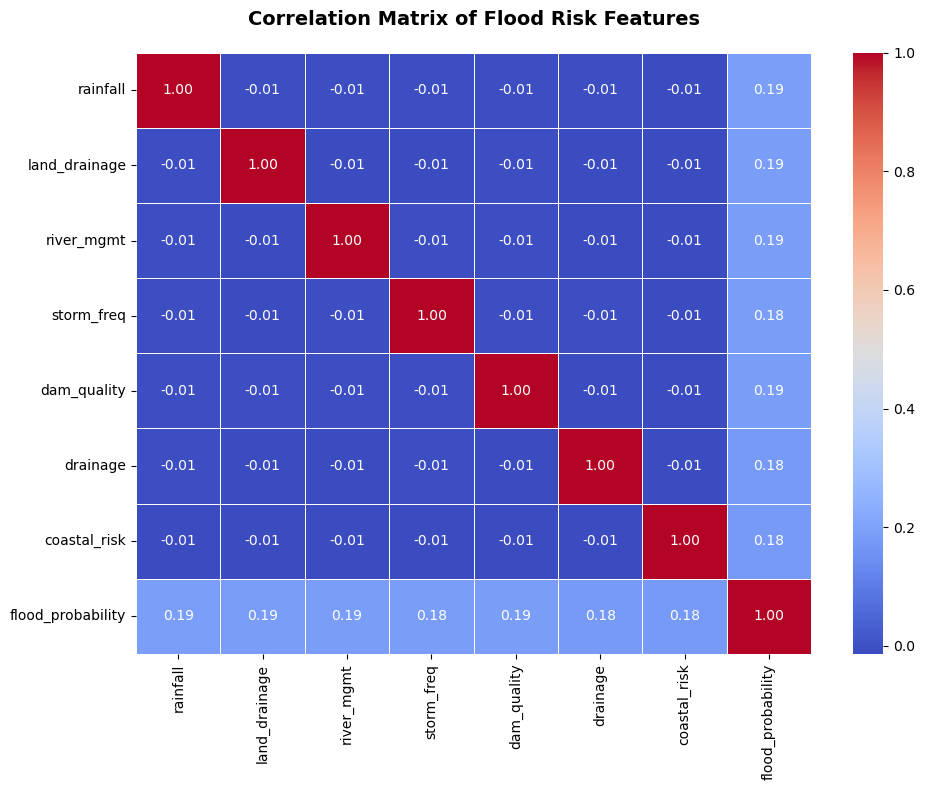

In [23]:
# GRAPH 1: CORRELATION HEATMAP
# Objective: Identify which features have the strongest relationship with flood probability.

# 1. Calculate the correlation matrix for all features
corr_matrix = df_clean.corr()

# 2. Set up the matplotlib figure size
plt.figure(figsize=(10, 8))

# 3. Create the heatmap using Seaborn
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# 4. Add Title and Layout Adjustments
plt.title("Correlation Matrix of Flood Risk Features", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()

# 5. Display the graph
plt.show()

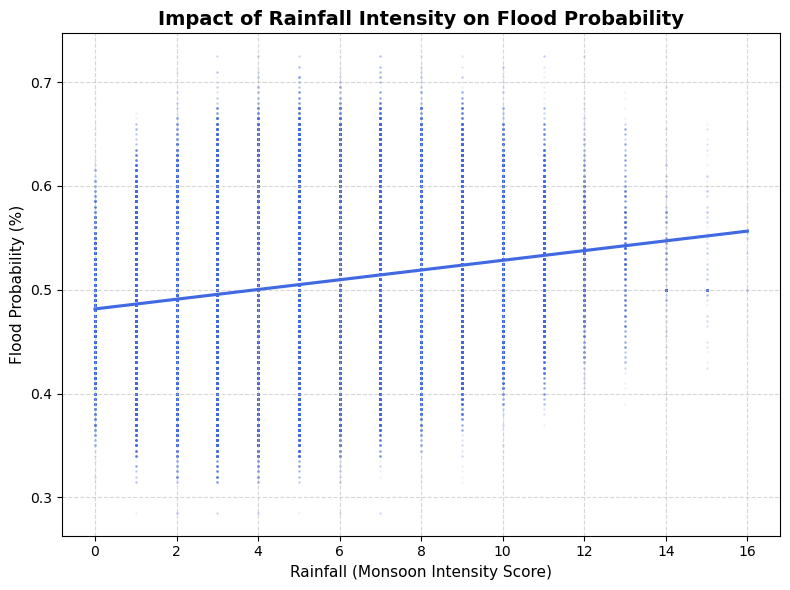

In [27]:
# GRAPH 2: SCATTER PLOT WITH REGRESSION LINE
# Objective: Visualize the trend between 'rainfall' (Monsoon Intensity) and 'flood_probability'.

plt.figure(figsize=(8, 6))
sns.regplot(data=df_clean, x="rainfall", y="flood_probability", 
            color="royalblue", scatter_kws={"alpha": 0.05, "s": 1})

# Add titles and labels
plt.title("Impact of Rainfall Intensity on Flood Probability", fontsize=14, fontweight="bold")
plt.xlabel("Rainfall (Monsoon Intensity Score)", fontsize=11)
plt.ylabel("Flood Probability (%)", fontsize=11)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# Display the graph
plt.show()

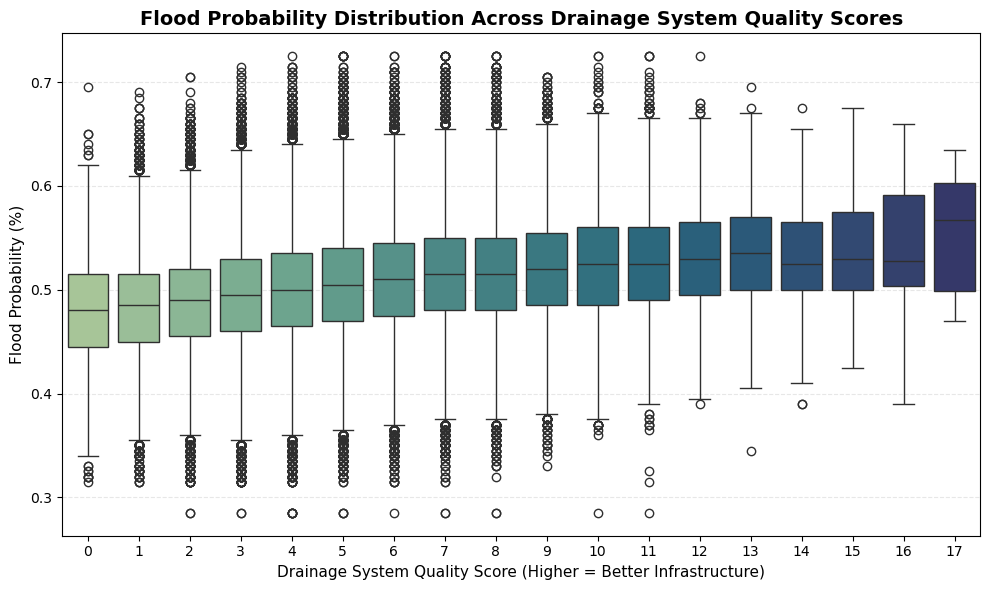

In [47]:
# GRAPH 3: BOX PLOT (FIXED WARNING VERSION)
# Objective: Compare Drainage System quality scores with Flood Probability.


plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x="drainage", y="flood_probability", 
            hue="drainage", palette="crest", legend=False)

# Add titles and labels
plt.title("Flood Probability Distribution Across Drainage System Quality Scores", fontsize=14, fontweight="bold")
plt.xlabel("Drainage System Quality Score (Higher = Better Infrastructure)", fontsize=11)
plt.ylabel("Flood Probability (%)", fontsize=11)

plt.grid(True, linestyle="--", alpha=0.3, axis="y")
plt.tight_layout()

# Display the graph
plt.show()

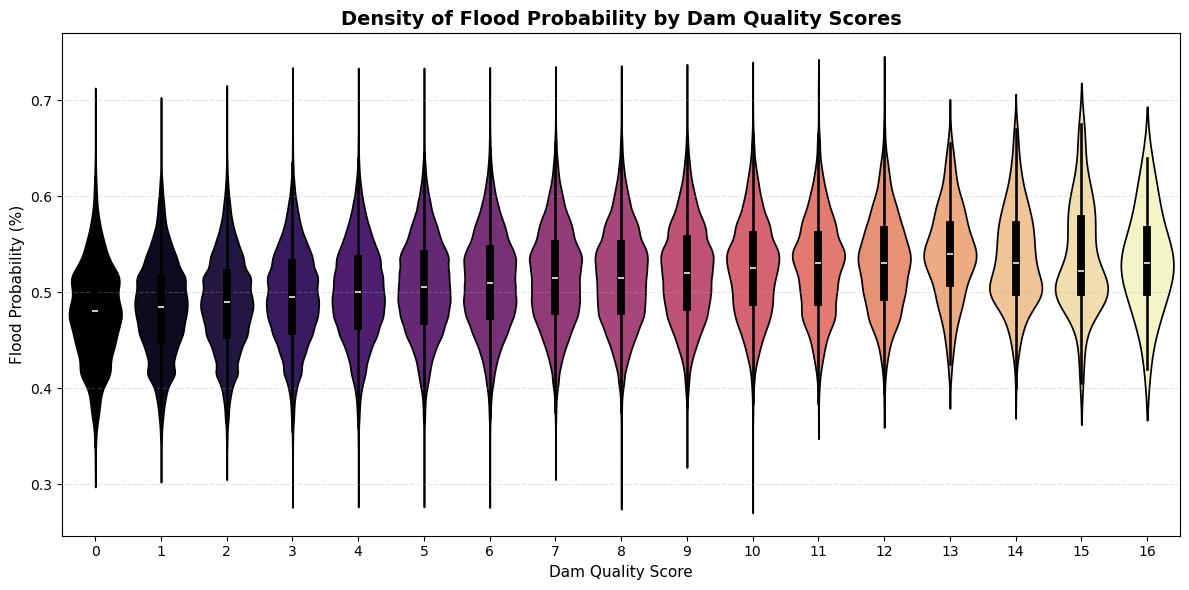

In [49]:
# GRAPH 4: VIOLIN PLOT (FIXED WARNING VERSION)
# Objective: Show the density and distribution of Flood Probability for each Dam Quality score.

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_clean, x="dam_quality", y="flood_probability", 
               hue="dam_quality", palette="magma", legend=False)

# Add titles and labels
plt.title("Density of Flood Probability by Dam Quality Scores", fontsize=14, fontweight="bold")
plt.xlabel("Dam Quality Score", fontsize=11)
plt.ylabel("Flood Probability (%)", fontsize=11)

plt.grid(True, linestyle="--", alpha=0.3, axis="y")
plt.tight_layout()

# Display the graph
plt.show()

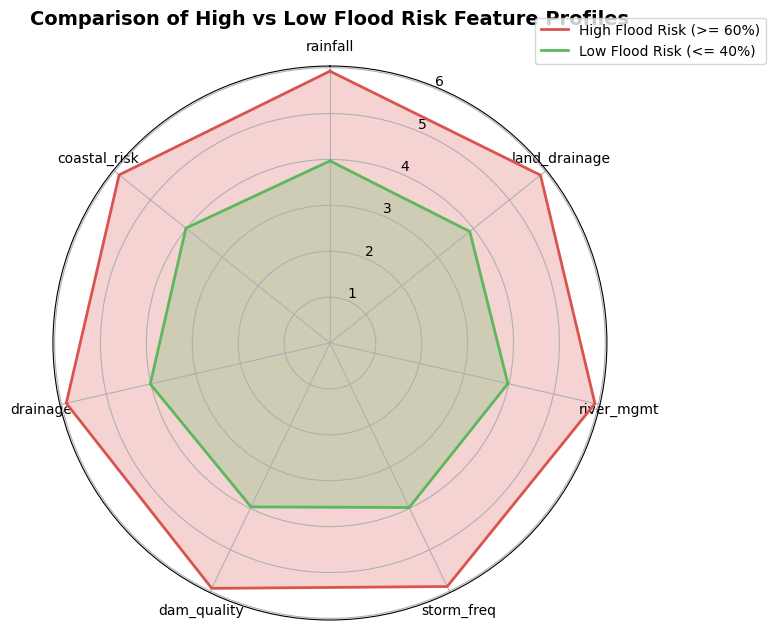

In [50]:
# GRAPH 5: RADAR CHART (SPIDER PLOT)
# Objective: Compare feature averages between High Risk and Low Risk flood groups.

# 1. Define High Risk (> 60%) and Low Risk (< 40%) groups based on flood_probability
high_risk = df_clean[df_clean['flood_probability'] >= 0.60]
low_risk = df_clean[df_clean['flood_probability'] <= 0.40]

# 2. Calculate the mean values for our 7 features
features = ['rainfall', 'land_drainage', 'river_mgmt', 'storm_freq', 'dam_quality', 'drainage', 'coastal_risk']
high_mean = high_risk[features].mean().tolist()
low_mean = low_risk[features].mean().tolist()

# 3. Close the circular loop for radar chart (repeat the first value at the end)
high_mean += high_mean[:1]
low_mean += low_mean[:1]
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]
feature_labels = features + [features[0]]

# 4. Plot the Radar Chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Draw High Risk Area (Red)
ax.plot(angles, high_mean, color='#d9534f', linewidth=2, label='High Flood Risk (>= 60%)')
ax.fill(angles, high_mean, color='#d9534f', alpha=0.25)

# Draw Low Risk Area (Green)
ax.plot(angles, low_mean, color='#5cb85c', linewidth=2, label='Low Flood Risk (<= 40%)')
ax.fill(angles, low_mean, color='#5cb85c', alpha=0.25)

# Fix labels and styling
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), features)

# Title and Legend
plt.title("Comparison of High vs Low Flood Risk Feature Profiles", fontsize=14, fontweight="bold", pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()

# Display the graph
plt.show()

# ⚖️ Part 4: Feature Scaling
In this section, we apply **StandardScaler** to normalize our 7 independent features. This ensures that all features contribute equally to the machine learning model training process and prevents numerical bias.

In [52]:
# SEPARATE FEATURES (X) AND TARGET (y)

# Define the list of 7 input features we want to scale
feature_cols = ['rainfall', 'land_drainage', 'river_mgmt', 'storm_freq', 'dam_quality', 'drainage', 'coastal_risk']

# Extract input features into X
X = df_clean[feature_cols]

# Extract the target variable into y (Keep it safe and separate)
y = df_clean['flood_probability']

print("Features (X) and Target (y) have been separated successfully.")
print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

Features (X) and Target (y) have been separated successfully.
Features shape (X): (1097096, 7)
Target shape (y): (1097096,)


In [53]:
# APPLY STANDARD SCALER

# 1. Initialize the StandardScaler object
scaler = StandardScaler()

# 2. Fit and transform the features data
X_scaled_array = scaler.fit_transform(X)

# 3. Convert the scaled array back into a clean Pandas DataFrame
X_scaled = pd.DataFrame(X_scaled_array, columns=feature_cols)

print("--- Feature Scaling Complete ---")
print("First 3 rows of scaled features:")
display(X_scaled.head(3))

--- Feature Scaling Complete ---
First 3 rows of scaled features:


,rainfall,land_drainage,river_mgmt,storm_freq,dam_quality,drainage,coastal_risk
0,0.036238,1.458863,0.019727,-0.453646,-0.458672,0.023723,-0.932777
1,0.520098,0.983566,-0.460570,1.480918,-0.936405,0.984140,-1.409240
2,0.520098,0.032970,0.500024,0.997277,-1.891872,0.984140,-0.932777


# 💾 Part 5: Data Export
In this final section, we combine our scaled input features with the original target variable (`flood_probability`) and export the complete, processed dataset into a new CSV file for the machine learning modeling team.

In [57]:
# COMBINE SCALED FEATURES AND TARGET

# Merging X_scaled and y side-by-side using concatenation.
df_final = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

print("--- Data Merging Complete ---")
print(f"Final Dataset Shape: {df_final.shape}")
print("\nFirst 5 rows of the final processed dataset:")

display(df_final.head())

--- Data Merging Complete ---
Final Dataset Shape: (1097096, 8)

First 5 rows of the final processed dataset:


,rainfall,land_drainage,river_mgmt,storm_freq,dam_quality,drainage,coastal_risk,flood_probability
0,0.036238,1.458863,0.019727,-0.453646,-0.458672,0.023723,-0.932777,0.445
1,0.520098,0.983566,-0.460570,1.480918,-0.936405,0.984140,-1.409240,0.450
2,0.520098,0.032970,0.500024,0.997277,-1.891872,0.984140,-0.932777,0.530
3,-0.931481,-0.442327,0.500024,1.480918,-0.458672,-1.416902,-0.456313,0.535
4,0.036238,-0.917625,-1.421164,-0.453646,-0.936405,-1.416902,-1.409240,0.415


In [61]:
# EXPORT TO CSV FILE

# Exporting the cleaned, scaled, and structured data
output_filename = "flood_processed_train_data.csv"
df_final.to_csv(output_filename, index=False)

print(f"🎉 SUCCESS: Completely processed dataset has been saved as '{output_filename}'!")
print("This file is now 100% ready for the model training stage.")

🎉 SUCCESS: Completely processed dataset has been saved as 'flood_processed_train_data.csv'!
This file is now 100% ready for the model training stage.
